<a href="https://colab.research.google.com/github/szuhow/label-studio-ml-backend/blob/main/keyframes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
from scipy import ndimage
from skimage import morphology, measure, draw
import matplotlib.pyplot as plt
import cv2

class CoronaryKeyframeSelector:
    def __init__(self, masks, min_object_size=20):
        """
        masks: lista masek binarnych (numpy arrays) z kolejnych klatek
        min_object_size: minimalny rozmiar obiektu, poniżej którego obiekty są usuwane
        """
        self.masks = np.array(masks)
        self.n_frames = len(masks)
        self.min_object_size = min_object_size

    def compute_overlap_mask(self, threshold=0.3):
        """
        Tworzy maskę overlapping regions - odrzuca obszary występujące
        tylko w pojedynczych klatkach (prawdopodobne artefakty)
        """
        # Normalizuj do [0,1] i uśrednij
        mean_mask = np.mean(self.masks.astype(float), axis=0)

        # Zachowaj tylko regiony występujące w >threshold klatek
        overlap_mask = (mean_mask > threshold).astype(np.uint8)
        return overlap_mask

    def compute_frame_scores(self):
        """
        Oblicza multi-criteria score dla każdej klatki
        """
        overlap_mask = self.compute_overlap_mask()
        scores = []

        for i, mask in enumerate(self.masks):
            # Filtruj maskę przez overlap_mask
            filtered_mask = mask & overlap_mask

            # Usuń małe obiekty (szum) po wstępnym filtrowaniu
            processed_mask = morphology.remove_small_objects(filtered_mask.astype(bool), min_size=self.min_object_size).astype(np.uint8)

            # Kryterium 1: Powierzchnia naczyń
            vessel_area = np.sum(filtered_mask)

            # Kryterium 2: Spójność (mniej komponenty = lepiej)
            labeled, n_components = ndimage.label(processed_mask)

            # Kryterium 3: Topologia - wypełnienie dziur
            filled = ndimage.binary_fill_holes(processed_mask)
            holes_area = np.sum(filled) - vessel_area

            # Kryterium 4: Kompaktowość (vessel_area / convex_hull_area)
            if vessel_area > 0:
                hull = morphology.convex_hull_image(processed_mask)
                compactness = vessel_area / (np.sum(hull) + 1e-6)
            else:
                compactness = 0

            # Kryterium 5: Średnica szkieletu (im dłuższy tym lepiej)
            skeleton = morphology.skeletonize(processed_mask)
            skeleton_length = np.sum(skeleton)

            scores.append({
                'frame_idx': i,
                'vessel_area': vessel_area,
                'n_components': n_components,
                'holes_area': holes_area,
                'compactness': compactness,
                'skeleton_length': skeleton_length
            })

        return scores

    def select_best_frame(self, weights=None):
        """
        Wybiera najlepszą klatkę na podstawie ważonej sumy kryteriów
        """
        if weights is None:
            weights = {
                'vessel_area': 0.4,
                'n_components': -0.2,  # ujemna waga - mniej jest lepiej
                'holes_area': -0.15,
                'compactness': 0.15,
                'skeleton_length': 0.2
            }

        scores = self.compute_frame_scores()

        # Normalizuj każde kryterium do [0,1]
        metrics = {k: [s[k] for s in scores] for k in scores[0].keys() if k != 'frame_idx'}

        normalized_scores = []
        for score in scores:
            norm_score = 0
            for metric, weight in weights.items():
                values = metrics[metric]
                min_val, max_val = min(values), max(values)

                if max_val > min_val:
                    norm_value = (score[metric] - min_val) / (max_val - min_val)
                else:
                    norm_value = 0

                norm_score += weight * norm_value

            normalized_scores.append(norm_score)

        best_idx = np.argmax(normalized_scores)

        return {
            'best_frame_idx': best_idx,
            'score': normalized_scores[best_idx],
            'all_scores': scores,
            'normalized_scores': normalized_scores
        }

    def visualize_selection(self, result):
        """
        Pomocnicza funkcja do wizualizacji wyników
        """
        best_idx = result['best_frame_idx']
        print(f"Wybrana klatka: {best_idx}")
        print(f"Score: {result['score']:.3f}")
        print(f"\nMetryki wybranej klatki:")
        for k, v in result['all_scores'][best_idx].items():
            if k != 'frame_idx':
                print(f"  {k}: {v:.2f}")


def generate_synthetic_coronary_masks(n_frames=20, img_size=(256, 256)):
    """
    Generuje syntetyczne maski naczyń wieńcowych dla testowania
    """
    masks = []

    # Główne drzewo naczyniowe (stabilne)
    main_tree_center = (img_size[0] // 2, img_size[1] // 2)

    for i in range(n_frames):
        mask = np.zeros(img_size, dtype=np.uint8)

        # Fazowanie serca - symuluje ruch naczyń
        phase = i / n_frames * 2 * np.pi
        offset_x = int(10 * np.sin(phase))
        offset_y = int(10 * np.cos(phase))

        # Główne naczynie - pień
        trunk_start = (main_tree_center[0] + offset_x, main_tree_center[1] + offset_y)
        trunk_end = (trunk_start[0] + 80, trunk_start[1] + 20)
        rr, cc = draw.line(trunk_start[0], trunk_start[1], trunk_end[0], trunk_end[1])
        # Pogrub naczynie
        for r, c in zip(rr, cc):
            cv2.circle(mask, (c, r), 4, 1, -1)

        # Gałęzie boczne
        # Gałąź 1
        branch1_start = (trunk_start[0] + 30, trunk_start[1] + 10)
        branch1_end = (branch1_start[0] + 40, branch1_start[1] - 50)
        rr, cc = draw.line(branch1_start[0], branch1_start[1], branch1_end[0], branch1_end[1])
        for r, c in zip(rr, cc):
            cv2.circle(mask, (c, r), 3, 1, -1)

        # Gałąź 2
        branch2_start = (trunk_start[0] + 50, trunk_start[1] + 15)
        branch2_end = (branch2_start[0] + 30, branch2_start[1] + 60)
        rr, cc = draw.line(branch2_start[0], branch2_start[1], branch2_end[0], branch2_end[1])
        for r, c in zip(rr, cc):
            cv2.circle(mask, (c, r), 3, 1, -1)

        # Symuluj różną widoczność naczyń w różnych fazach
        # W fazach 0.3-0.7 naczynia są najbardziej widoczne (najlepsza faza)
        visibility = 1.0 - 0.5 * abs(np.sin(phase - np.pi/2))

        if visibility < 0.6:
            # W złych fazach: dodaj disconnected fragments
            # Artefakt 1
            if i % 4 == 0:
                cv2.circle(mask, (50, 50), 8, 1, -1)
            # Artefakt 2
            if i % 3 == 0:
                cv2.circle(mask, (200, 200), 6, 1, -1)

        # W środkowych klatkach (najlepsza faza) dodaj więcej szczegółów
        if 6 <= i <= 14:
            # Małe gałązki końcowe
            subbranch_start = (branch1_end[0] + 10, branch1_end[1] - 5)
            subbranch_end = (subbranch_start[0] + 15, subbranch_start[1] - 20)
            rr, cc = draw.line(subbranch_start[0], subbranch_start[1],
                              subbranch_end[0], subbranch_end[1])
            for r, c in zip(rr, cc):
                cv2.circle(mask, (c, r), 2, 1, -1)

        # Dodaj szum
        noise = np.random.random(img_size) > 0.98
        mask = np.logical_or(mask, noise).astype(np.uint8)

        masks.append(mask)

    return masks


def visualize_comprehensive_results(masks, selector, result):
    """
    Kompleksowa wizualizacja wyników
    """
    best_idx = result['best_frame_idx']
    scores = result['all_scores']
    normalized_scores = result['normalized_scores']
    overlap_mask = selector.compute_overlap_mask() # Recompute overlap mask for visualization

    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(4, 5, hspace=0.3, wspace=0.3)

    # 1. Wykres normalized scores
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(normalized_scores, 'b-o', linewidth=2, markersize=8, label='Normalized Score')
    ax1.axvline(best_idx, color='r', linestyle='--', linewidth=2, label=f'Best Frame: {best_idx}')
    ax1.set_xlabel('Frame Index', fontsize=12)
    ax1.set_ylabel('Normalized Score', fontsize=12)
    ax1.set_title('Frame Scores Over Time', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # 2. Individual metrics
    metrics = ['vessel_area', 'n_components', 'holes_area', 'compactness', 'skeleton_length']
    colors = ['blue', 'red', 'green', 'orange', 'purple']

    for idx, (metric, color) in enumerate(zip(metrics, colors)):
        ax = fig.add_subplot(gs[1, idx])
        values = [s[metric] for s in scores]
        ax.plot(values, color=color, linewidth=2, marker='o', markersize=5)
        ax.axvline(best_idx, color='red', linestyle='--', alpha=0.5)
        ax.set_title(metric.replace('_', ' ').title(), fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Frame')

    # 3. Overlap mask
    ax_overlap = fig.add_subplot(gs[2, 0])
    ax_overlap.imshow(overlap_mask, cmap='hot')
    ax_overlap.set_title('Overlap Mask', fontsize=11, fontweight='bold')
    ax_overlap.axis('off')

    # 4. Best frame - original
    ax_best = fig.add_subplot(gs[2, 1])
    ax_best.imshow(masks[best_idx], cmap='gray')
    ax_best.set_title(f'Best Frame #{best_idx}\nRaw Mask', fontsize=11, fontweight='bold')
    ax_best.axis('off')

    # 5. Best frame - filtered (and small objects removed)
    ax_filtered = fig.add_subplot(gs[2, 2])
    filtered = masks[best_idx] & overlap_mask
    processed_mask_for_viz = morphology.remove_small_objects(filtered.astype(bool), min_size=selector.min_object_size).astype(np.uint8)
    ax_filtered.imshow(processed_mask_for_viz, cmap='gray')
    ax_filtered.set_title(f'Best Frame #{best_idx}\nFiltered & Cleaned', fontsize=11, fontweight='bold')
    ax_filtered.axis('off')

    # 6. Best frame - skeleton
    ax_skel = fig.add_subplot(gs[2, 3])
    skeleton = morphology.skeletonize(processed_mask_for_viz)
    ax_skel.imshow(skeleton, cmap='gray')
    ax_skel.set_title(f'Skeleton\nLength: {np.sum(skeleton)}', fontsize=11, fontweight='bold')
    ax_skel.axis('off')

    # 7. Connected components
    ax_comp = fig.add_subplot(gs[2, 4])
    labeled, n_comp = ndimage.label(processed_mask_for_viz)
    ax_comp.imshow(labeled, cmap='nipy_spectral')
    ax_comp.set_title(f'Components: {n_comp}', fontsize=11, fontweight='bold')
    ax_comp.axis('off')

    # 8. Sample frames comparison
    sample_indices = [0, best_idx // 2, best_idx, (best_idx + len(masks)) // 2, len(masks) - 1]
    for i, frame_idx in enumerate(sample_indices):
        ax = fig.add_subplot(gs[3, i])
        current_filtered_mask = masks[frame_idx] & overlap_mask
        current_processed_mask = morphology.remove_small_objects(current_filtered_mask.astype(bool), min_size=selector.min_object_size).astype(np.uint8)
        ax.imshow(current_processed_mask, cmap='gray')
        border_color = 'red' if frame_idx == best_idx else 'blue'
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3 if frame_idx == best_idx else 1)
        ax.set_title(f'Frame {frame_idx}\nScore: {normalized_scores[frame_idx]:.3f}',
                    fontsize=9)
        ax.axis('off')

    plt.suptitle('Coronary Keyframe Selection - Comprehensive Analysis',
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('keyframe_analysis.png', dpi=150, bbox_inches='tight')
    print("\n✅ Visualizacja zapisana jako 'keyframe_analysis.png'")
    plt.show()


def run_comprehensive_test(masks=None, n_frames=20, img_size=(256, 256), min_object_size=20):
    """
    Główna funkcja testowa
    """
    print("=" * 80)
    print("TEST ALGORYTMU CORONARY KEYFRAME SELECTOR")
    print("=" * 80)

    # 1. Generuj syntetyczne dane lub użyj dostarczonych
    if masks is None:
        print("\n[1/4] Generowanie syntetycznych masek naczyń wieńcowych...")
        masks = generate_synthetic_coronary_masks(n_frames=n_frames, img_size=img_size)
        print(f"   ✓ Wygenerowano {len(masks)} klatek o rozmiarze {masks[0].shape}")
    else:
        print("\n[1/4] Użycie dostarczonych masek naczyń wieńcowych...")
        print(f"   ✓ Załadowano {len(masks)} klatek o rozmiarze {masks[0].shape}")

    if not masks:
        print("Brak masek do przetworzenia. Zakończono test.")
        return

    # 2. Inicjalizuj selektor
    print("\n[2/4] Inicjalizacja selektora...")
    selector = CoronaryKeyframeSelector(masks, min_object_size=min_object_size)
    print(f"   ✓ Załadowano {selector.n_frames} klatek")
    print(f"   ✓ Obiekty mniejsze niż {selector.min_object_size} pikseli zostaną usunięte.")

    # 3. Oblicz scores
    print("\n[3/4] Obliczanie scores dla wszystkich klatek...")
    result = selector.select_best_frame()

    # 4. Wyświetl wyniki
    print("\n[4/4] Wyniki selekcji:")
    print("-" * 80)
    selector.visualize_selection(result)

    # Dodatkowe statystyki
    print("\n" + "=" * 80)
    print("STATYSTYKI WSZYSTKICH KLATEK:")
    print("=" * 80)
    print(f"{'Frame':<8} {'Score':<10} {'Area':<10} {'Comp':<8} {'Holes':<10} {'Compact':<10} {'Skel':<10}")
    print("-" * 80)
    for i, (score, metrics) in enumerate(zip(result['normalized_scores'], result['all_scores'])):
        print(f"{i:<8} {score:<10.4f} {metrics['vessel_area']:<10.0f} "
              f"{metrics['n_components']:<8} {metrics['holes_area']:<10.0f} "
              f"{metrics['compactness']:<10.4f} "
              f"{metrics['skeleton_length']:<10.0f}")

    # 5. Wizualizacja
    print("\n[5/5] Generowanie kompleksowej wizualizacji...")
    visualize_comprehensive_results(masks, selector, result)

    # 6. Test z różnymi wagami
    print("\n" + "=" * 80)
    print("TEST Z RÓŻNYMI WAGAMI:")
    print("=" * 80)

    weight_configs = [
        {'name': 'Domyślne', 'weights': None},
        {'name': 'Focus na powierzchnię', 'weights': {
            'vessel_area': 0.8, 'n_components': -0.1, 'holes_area': -0.05,
            'compactness': 0.0, 'skeleton_length': 0.15
        }},
        {'name': 'Focus na spójność', 'weights': {
            'vessel_area': 0.2, 'n_components': -0.5, 'holes_area': -0.2,
            'compactness': 0.1, 'skeleton_length': 0.0
        }},
        {'name': 'Focus na długość szkieletu', 'weights': {
            'vessel_area': 0.2, 'n_components': -0.1, 'holes_area': -0.1,
            'compactness': 0.1, 'skeleton_length': 0.7
        }}
    ]

    for config in weight_configs:
        result = selector.select_best_frame(weights=config['weights'])
        print(f"\n{config['name']}: Frame {result['best_frame_idx']} "
              f"(score: {result['score']:.4f})")

    print("\n" + "=" * 80)
    print("TEST ZAKOŃCZONY POMYŚLNIE! ✅")
    print("=" * 80)

In [19]:
import os
import cv2
import numpy as np
import re # Import regex for natural sorting

def natural_sort_key(s):
    # Function to extract numbers for natural sorting
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

def load_masks_from_directory(directory_path):
    masks = []
    original_filenames = [] # To store original filenames
    # Get all PNG files and sort them naturally by filename to maintain frame order
    mask_files = sorted([f for f in os.listdir(directory_path) if f.endswith('_pred.png')], key=natural_sort_key)

    print(f"Found {len(mask_files)} mask files in '{directory_path}'")

    if not mask_files:
        print("No mask files found. Please ensure the 'data' folder contains PNG images.")
        return [], [] # Return empty lists for masks and filenames

    for filename in mask_files:
        filepath = os.path.join(directory_path, filename)
        # Read image in grayscale
        mask_img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        if mask_img is None:
            print(f"Warning: Could not read {filepath}")
            continue
        # Convert to binary mask (0 or 1)
        binary_mask = (mask_img > 0).astype(np.uint8)
        masks.append(binary_mask)
        original_filenames.append(filename) # Store the filename

    return masks, original_filenames

# Specify the directory where the masks are located
data_directory = '/content/data'

# Load the masks and their filenames
loaded_masks, loaded_filenames = load_masks_from_directory(data_directory)

if loaded_masks:
    print(f"Successfully loaded {len(loaded_masks)} masks with shape {loaded_masks[0].shape}")
    # print(f"Loaded filenames (first 5): {loaded_filenames[:5]}") # For debugging if needed
else:
    print("No masks were loaded. The CoronaryKeyframeSelector cannot be initialized.")

Found 45 mask files in '/content/data'
Successfully loaded 45 masks with shape (512, 512)


In [18]:
def run_comprehensive_test(masks=None, n_frames=20, img_size=(256, 256), min_object_size=20, frame_names=None):
    """
    Główna funkcja testowa
    """
    print("=" * 80)
    print("TEST ALGORYTMU CORONARY KEYFRAME SELECTOR")
    print("=" * 80)

    # 1. Generuj syntetyczne dane lub użyj dostarczonych
    if masks is None:
        print("\n[1/4] Generowanie syntetycznych masek naczyń wieńcowych...")
        masks = generate_synthetic_coronary_masks(n_frames=n_frames, img_size=img_size)
        # If generating synthetic masks, generate simple index-based frame names
        frame_names = [f"Synthetic_{i}.png" for i in range(len(masks))]
        print(f"   ✓ Wygenerowano {len(masks)} klatek o rozmiarze {masks[0].shape}")
    else:
        print("\n[1/4] Użycie dostarczonych masek naczyń wieńcowych...")
        print(f"   ✓ Załadowano {len(masks)} klatek o rozmiarze {masks[0].shape}")
        # If real masks are provided without names, generate index-based names as fallback
        if frame_names is None or len(frame_names) != len(masks):
            frame_names = [f"Frame_{i}.png" for i in range(len(masks))]

    if not masks:
        print("Brak masek do przetworzenia. Zakończono test.")
        return

    # 2. Inicjalizuj selektor
    print("\n[2/4] Inicjalizacja selektora...")
    selector = CoronaryKeyframeSelector(masks, min_object_size=min_object_size)
    print(f"   ✓ Załadowano {selector.n_frames} klatek")
    print(f"   ✓ Obiekty mniejsze niż {selector.min_object_size} pikseli zostaną usunięte.")

    # 3. Oblicz scores
    print("\n[3/4] Obliczanie scores dla wszystkich klatek...")
    result = selector.select_best_frame()

    # 4. Wyświetl wyniki
    print("\n[4/4] Wyniki selekcji:")
    print("-" * 80)
    selector.visualize_selection(result)

    # Dodatkowe statystyki
    print("\n" + "=" * 80)
    print("STATYSTYKI WSZYSTKICH KLATEK:")
    print("=" * 80)
    # Updated table header to include 'Filename'
    print(f"{'Frame':<8} {'Filename':<40} {'Score':<10} {'Area':<10} {'Comp':<8} {'Holes':<10} {'Compact':<10} {'Skel':<10}")
    print("-" * 80)
    for i, (score, metrics) in enumerate(zip(result['normalized_scores'], result['all_scores'])):
        # Get the filename for the current frame, fallback to generic name if not available
        filename_to_display = frame_names[i] if i < len(frame_names) else f"Frame_{i}.png"
        print(f"{i:<8} {filename_to_display:<40} {score:<10.4f} {metrics['vessel_area']:<10.0f} "
              f"{metrics['n_components']:<8} {metrics['holes_area']:<10.0f} "
              f"{metrics['compactness']:<10.4f} "
              f"{metrics['skeleton_length']:<10.0f}")

    # 5. Wizualizacja
    print("\n[5/5] Generowanie kompleksowej wizualizacji...")
    # Note: visualize_comprehensive_results does not currently display filenames in plots
    visualize_comprehensive_results(masks, selector, result)

    # 6. Test z różnymi wagami
    print("\n" + "=" * 80)
    print("TEST Z RÓŻNYMI WAGAMI:")
    print("=" * 80)

    weight_configs = [
        {'name': 'Domyślne', 'weights': None},
        {'name': 'Focus na powierzchnię', 'weights': {
            'vessel_area': 0.8, 'n_components': -0.1, 'holes_area': -0.05,
            'compactness': 0.0, 'skeleton_length': 0.15
        }},
        {'name': 'Focus na spójność', 'weights': {
            'vessel_area': 0.2, 'n_components': -0.5, 'holes_area': -0.2,
            'compactness': 0.1, 'skeleton_length': 0.0
        }},
        {'name': 'Focus na długość szkieletu', 'weights': {
            'vessel_area': 0.2, 'n_components': -0.1, 'holes_area': -0.1,
            'compactness': 0.1, 'skeleton_length': 0.7
        }}
    ]

    for config in weight_configs:
        result = selector.select_best_frame(weights=config['weights'])
        # Display filename for the best frame in each weight config test
        best_frame_filename = frame_names[result['best_frame_idx']] if result['best_frame_idx'] < len(frame_names) else f"Frame_{result['best_frame_idx']}.png"
        print(f"\n{config['name']}: Frame {result['best_frame_idx']} (Filename: {best_frame_filename}) "
              f"(score: {result['score']:.4f})")

    print("\n" + "=" * 80)
    print("TEST ZAKOŃCZONY POMYŚLNIE! ✅")
    print("=" * 80)

TEST ALGORYTMU CORONARY KEYFRAME SELECTOR

[1/4] Użycie dostarczonych masek naczyń wieńcowych...
   ✓ Załadowano 45 klatek o rozmiarze (512, 512)

[2/4] Inicjalizacja selektora...
   ✓ Załadowano 45 klatek
   ✓ Obiekty mniejsze niż 20 pikseli zostaną usunięte.

[3/4] Obliczanie scores dla wszystkich klatek...

[4/4] Wyniki selekcji:
--------------------------------------------------------------------------------
Wybrana klatka: 14
Score: 0.465

Metryki wybranej klatki:
  vessel_area: 980.00
  n_components: 2.00
  holes_area: -43.00
  compactness: 0.21
  skeleton_length: 148.00

STATYSTYKI WSZYSTKICH KLATEK:
Frame    Filename                                 Score      Area       Comp     Holes      Compact    Skel      
--------------------------------------------------------------------------------
0        10_I0572693.VIM.DCM.0_pred.png           -0.1500    0          0        0          0.0000     0         
1        10_I0572693.VIM.DCM.1_pred.png           -0.1500    0          0   

/tmp/ipython-input-297222366.py:289: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



✅ Visualizacja zapisana jako 'keyframe_analysis.png'


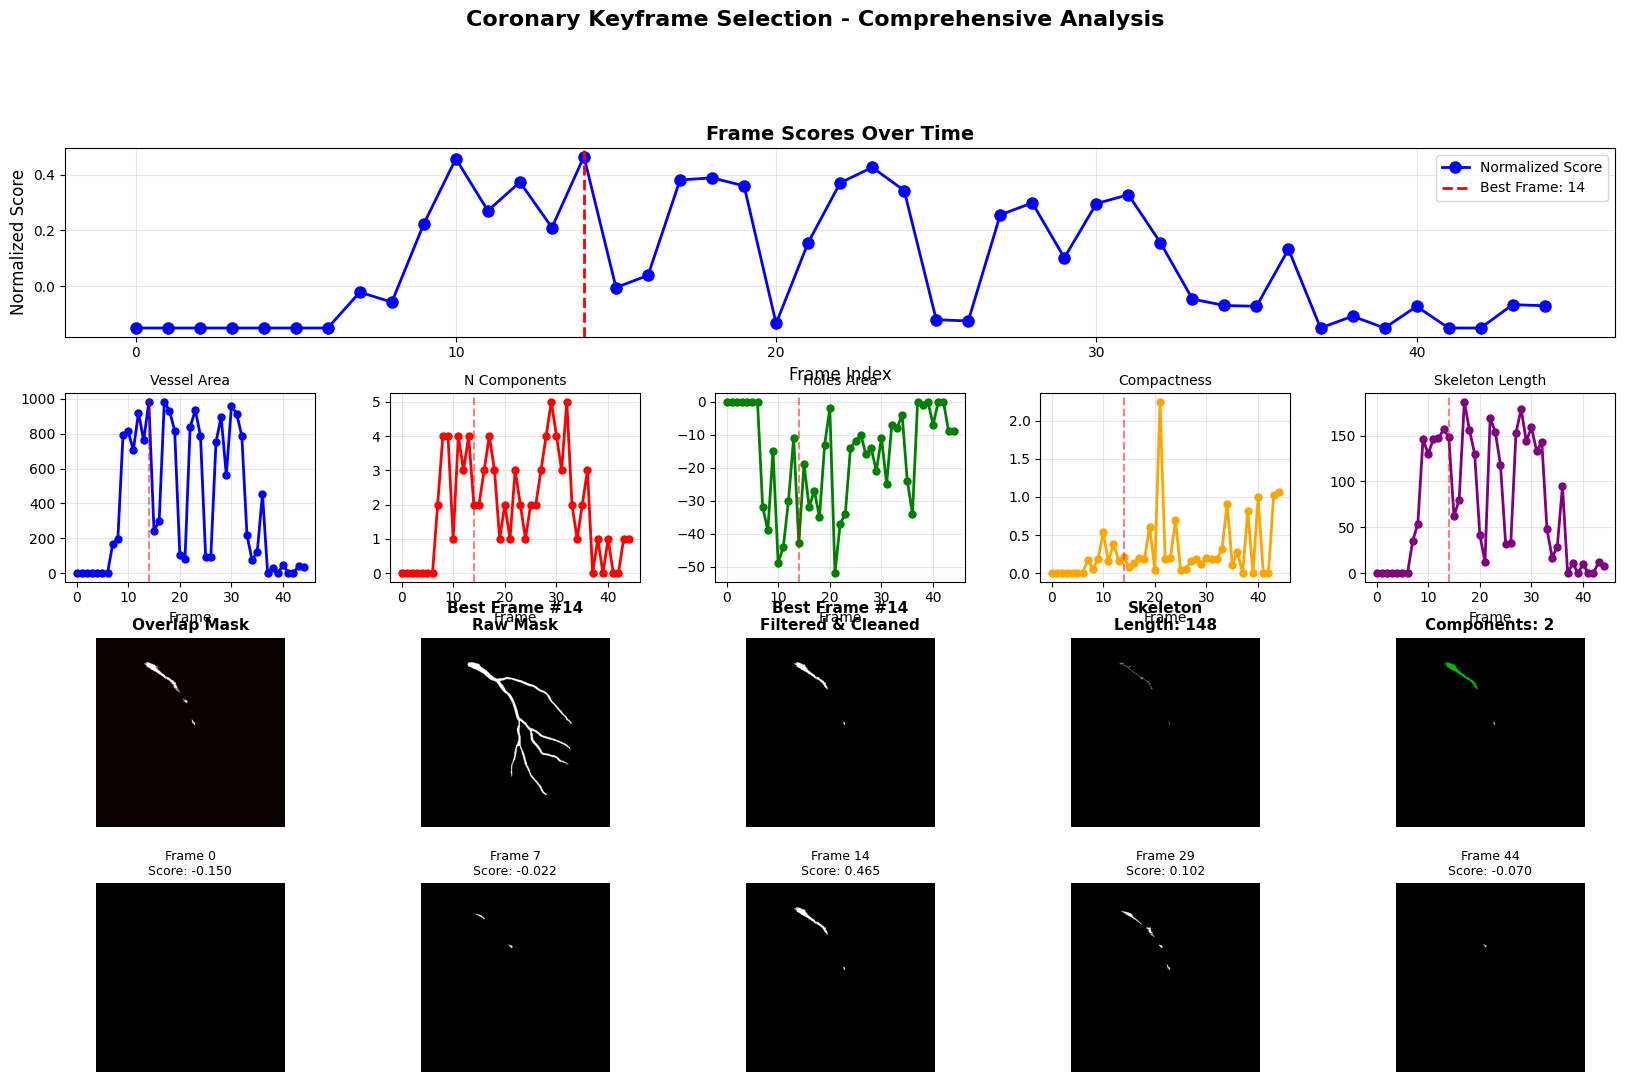


TEST Z RÓŻNYMI WAGAMI:

Domyślne: Frame 14 (Filename: 10_I0572693.VIM.DCM.14_pred.png) (score: 0.4649)

Focus na powierzchnię: Frame 14 (Filename: 10_I0572693.VIM.DCM.14_pred.png) (score: 0.8676)

Focus na spójność: Frame 10 (Filename: 10_I0572693.VIM.DCM.10_pred.png) (score: 0.0778)

Focus na długość szkieletu: Frame 17 (Filename: 10_I0572693.VIM.DCM.17_pred.png) (score: 0.7806)

TEST ZAKOŃCZONY POMYŚLNIE! ✅


In [20]:
if loaded_masks:
    run_comprehensive_test(masks=loaded_masks, frame_names=loaded_filenames)
else:
    print("Skipping comprehensive test because no masks were loaded.")

In [ ]:
#